<a href="https://colab.research.google.com/github/ddeekshitha0099-dotcom/calculating-family-expences/blob/main/FUTURE_ML_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Forecasting Project

### Objective
Build a model to forecast future sales using historical business data.

### Skills Demonstrated
- Data Cleaning
- Time-based Feature Engineering
- Regression-based Forecasting
- Model Evaluation
- Visualization of Forecast Results


# Abstract



*This project focuses on forecasting future sales using historical business data. The dataset contains order details such as sales amount, quantity, category, and order date. Data preprocessing and feature engineering techniques were applied to prepare the dataset for machine learning. A regression model was used to predict future sales trends. The results were visualized using Python’s Matplotlib to help businesses understand demand patterns and make better inventory decisions.*

## Introduction

why sales forecasting is important.


Sales forecasting plays an important role in business planning and decision-making. By analyzing historical sales data, companies can predict future demand and optimize inventory, marketing, and supply chain operations. Machine learning techniques allow businesses to build predictive models that identify patterns in sales trends. In this project, a machine learning model is developed to forecast future sales using historical order data.

# Problem Statement

the problem clearly.



Businesses need accurate predictions of future sales to manage inventory and optimize supply chain operations. The objective of this project is to build a machine learning model that forecasts future sales based on historical order data.

## Step 1: Import Required Libraries


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Dataset Description

the dataset used.



The dataset used in this project contains 1194 records with the following attributes:

Column	Description
Order ID	Unique order identifier
Amount	Total sales amount
Profit	Profit from the order
Quantity	Number of items sold
Category	Product category
Sub-Category	Product type
PaymentMode	Payment method
Order Date	Date of order
CustomerName	Customer name
State	Customer location
City	Customer city

For forecasting purposes, the Order Date and Amount (sales) columns were used.

## Step 2: Load Dataset



In [9]:
df = pd.read_csv('/content/Sales Dataset.csv')
df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1   Amount        1194 non-null   int64 
 2   Profit        1194 non-null   int64 
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   CustomerName  1194 non-null   object
 9   State         1194 non-null   object
 10  City          1194 non-null   object
 11  Year-Month    1194 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.1+ KB


In [11]:
df.shape

(1194, 12)

In [12]:
df.size

14328

## Step 3: Data Cleaning

In [18]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [19]:
df.isnull().sum()

,0
Order ID,0
Amount,0
Quantity,0
Category,0
Sub-Category,0
PaymentMode,0
Order Date,0
CustomerName,0
State,0
City,0


In [20]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_2908/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


## step 4: Select Important Columns

In [21]:
sales_df = df[['Order Date','Amount']]
sales_df.head()

,Order Date,Amount
Profit,,
50,2022-03-08,6184
50,2022-12-08,6184
51,2021-03-24,1165
52,2022-03-28,4099
54,2021-05-25,815


## step 5:Group Sales by Date

In [22]:
sales_df = sales_df.groupby('Order Date').sum().reset_index()

## step 6: Set Date as Index

In [23]:
sales_df.set_index('Order Date', inplace=True)

sales_df.head()

,Amount
Order Date,
2020-03-22,8962
2020-03-23,2975
2020-03-31,11054
2020-04-02,11761
2020-04-04,22621


## step 7: Visualize Historical Sales

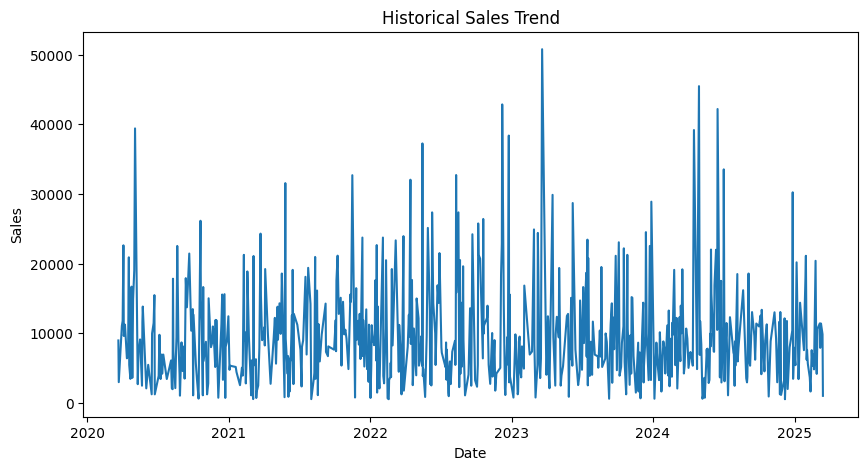

In [24]:
plt.figure(figsize=(10,5))

plt.plot(sales_df['Amount'])

plt.title("Historical Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

## step 8: Feature Engineering (Time Features)

In [25]:
sales_df['year'] = sales_df.index.year
sales_df['month'] = sales_df.index.month
sales_df['day'] = sales_df.index.day
sales_df['dayofweek'] = sales_df.index.dayofweek

In [26]:
sales_df['lag1'] = sales_df['Amount'].shift(1)

In [27]:
sales_df['rolling_mean'] = sales_df['Amount'].rolling(7).mean()

In [28]:
sales_df.dropna(inplace=True)

## step 9: Prepare Data for Model

In [29]:
X = sales_df[['year','month','day','dayofweek','lag1','rolling_mean']]

In [30]:
y = sales_df['Amount']

## step 10: Train Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

## step 11: Train Forecast Model

In [32]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## step 12: Predict Sales

In [33]:
predictions = model.predict(X_test)

## step 13: Model Evaluation

In [34]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 4633.066193864773
RMSE: 6619.003378138821


## step 14: Forecast Visualization

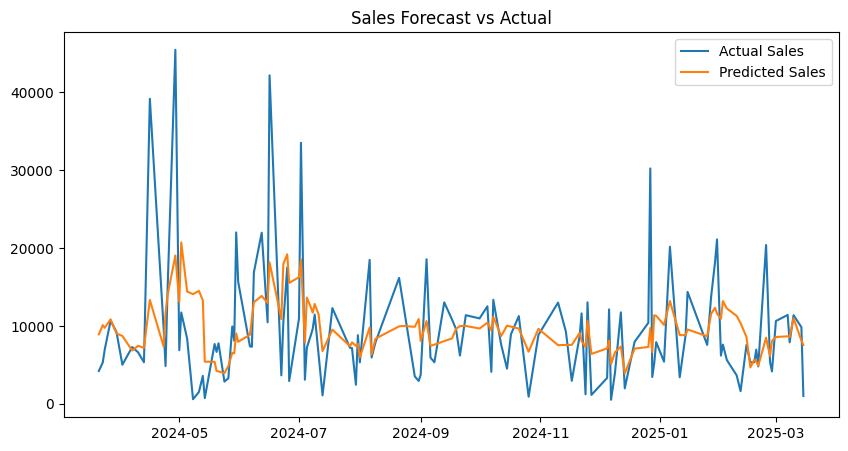

In [35]:
plt.figure(figsize=(10,5))

plt.plot(y_test.index, y_test, label="Actual Sales")

plt.plot(y_test.index, predictions, label="Predicted Sales")

plt.legend()

plt.title("Sales Forecast vs Actual")

plt.show()

## step 15: Future Sales Forecast

In [36]:
future_dates = pd.date_range(start=sales_df.index[-1], periods=30)

future_df = pd.DataFrame(index=future_dates)

In [37]:
future_df['year'] = future_df.index.year
future_df['month'] = future_df.index.month
future_df['day'] = future_df.index.day
future_df['dayofweek'] = future_df.index.dayofweek

future_df['lag1'] = sales_df['Amount'].iloc[-1]
future_df['rolling_mean'] = sales_df['Amount'].rolling(7).mean().iloc[-1]

In [38]:
future_sales = model.predict(future_df)

## step 16: Plot Future Forecast

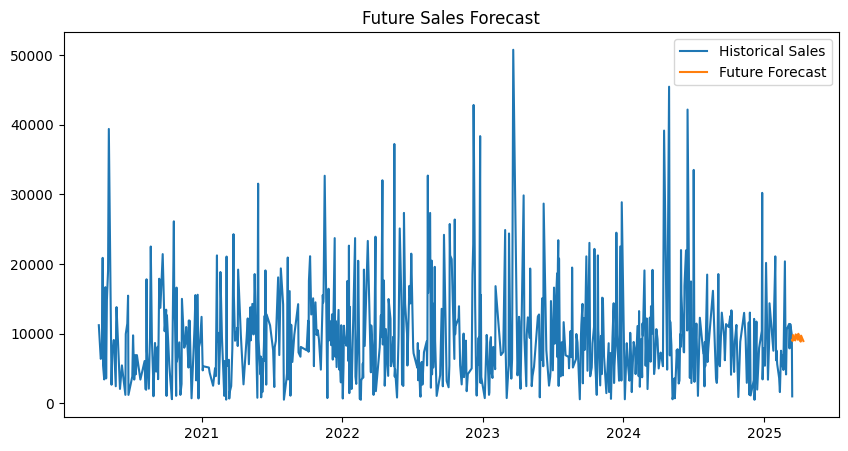

In [39]:
plt.figure(figsize=(10,5))

plt.plot(sales_df.index, sales_df['Amount'], label="Historical Sales")

plt.plot(future_dates, future_sales, label="Future Forecast")

plt.legend()

plt.title("Future Sales Forecast")

plt.show()

# Conclusion



This project demonstrates how machine learning techniques can be applied to forecast future sales based on historical data. The regression model successfully captured sales patterns and provided useful predictions. Future improvements may include advanced time-series models such as ARIMA, Prophet, or LSTM to improve forecasting accuracy.